# PLB simulation plots

This notebook compares round-robin and least-loaded runs using routing-state metrics.

Current model: one Batsim job = one BenchBase worker/session.

In [1]:
from pathlib import Path
from collections import defaultdict
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()

SCENARIO = "no_fault_3_classes"
REP = "rep_01"
POLICIES = ["round_robin", "least_loaded"]
THETA = 10

CLASS_ORDER = ["enterprise", "premium", "freemium"]

CLASS_COLORS = {
    "enterprise": "#CC79A7",
    "premium": "#E69F00",
    "freemium": "#0D7D87",
}

GRAY_COLORS = {
    "dark": "#5F6B73",
    "light": "#C9CFD6",
}

POLICY_COLORS = {
    "round_robin": GRAY_COLORS["dark"],
    "least_loaded": GRAY_COLORS["light"],
}

CLASS_PALETTE = CLASS_COLORS
POLICY_PALETTE = POLICY_COLORS

OUT = ROOT / "notebook_plots" / SCENARIO
OUT.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (8, 4.8),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.frameon": False,
})

## Load scheduler traces

In [2]:
def policy_dir(policy):
    return ROOT / "outputs" / SCENARIO / REP / policy

def read_decisions(policy):
    path = policy_dir(policy) / "scheduler_decisions.csv"
    if not path.exists():
        raise FileNotFoundError(path)
    df = pd.read_csv(path)
    df["policy"] = policy
    df["time_s"] = pd.to_numeric(df["time_s"])
    df["replica"] = pd.to_numeric(df["replica"], errors="coerce")
    return df

decisions = pd.concat([read_decisions(p) for p in POLICIES], ignore_index=True)
decisions.head()

,time_s,event,job_id,class,replica,slot,policy,active_total_after,active_by_class_after
0,0.642215,start,w0!w000000__freemium,freemium,0,0,round_robin,"{""0"": 1}","{""0"": {""freemium"": 1}}"
1,0.849197,start,w0!w000001__freemium,freemium,1,100,round_robin,"{""0"": 1, ""1"": 1}","{""0"": {""freemium"": 1}, ""1"": {""freemium"": 1}}"
2,1.127565,start,w0!w000002__freemium,freemium,2,200,round_robin,"{""0"": 1, ""1"": 1, ""2"": 1}","{""0"": {""freemium"": 1}, ""1"": {""freemium"": 1}, ""..."
3,1.264784,start,w0!w000003__enterprise,enterprise,3,300,round_robin,"{""0"": 1, ""1"": 1, ""2"": 1, ""3"": 1}","{""0"": {""freemium"": 1}, ""1"": {""freemium"": 1}, ""..."
4,1.358111,start,w0!w000004__enterprise,enterprise,4,400,round_robin,"{""0"": 1, ""1"": 1, ""2"": 1, ""3"": 1, ""4"": 1}","{""0"": {""freemium"": 1}, ""1"": {""freemium"": 1}, ""..."


## Job completion metrics

In [3]:
def read_metrics(policy):
    path = policy_dir(policy) / "metrics_by_class.csv"
    if not path.exists():
        return pd.DataFrame()
    df = pd.read_csv(path)
    df["policy"] = policy
    return df

metrics = pd.concat([read_metrics(p) for p in POLICIES], ignore_index=True)
metrics

,class,jobs,avg_waiting_time_s,p95_waiting_time_s,avg_turnaround_time_s,p95_turnaround_time_s,avg_execution_time_s,p95_execution_time_s,policy
0,enterprise,200,0.0,0.0,20.528027,28.540085,20.528027,28.540085,round_robin
1,freemium,200,0.0,0.0,20.004475,29.074023,20.004475,29.074023,round_robin
2,premium,200,0.0,0.0,19.820247,28.586135,19.820247,28.586135,round_robin
3,enterprise,200,0.0,0.0,20.528027,28.540085,20.528027,28.540085,least_loaded
4,freemium,200,0.0,0.0,20.004475,29.074023,20.004475,29.074023,least_loaded
5,premium,200,0.0,0.0,19.820247,28.586135,19.820247,28.586135,least_loaded


## Started sessions per replica

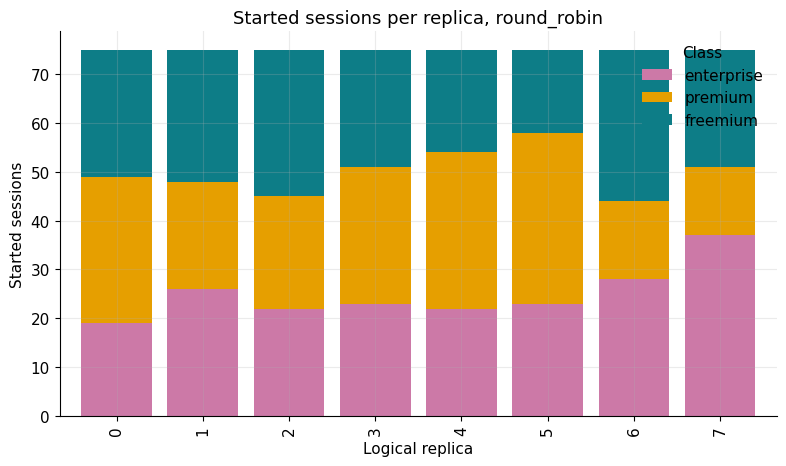

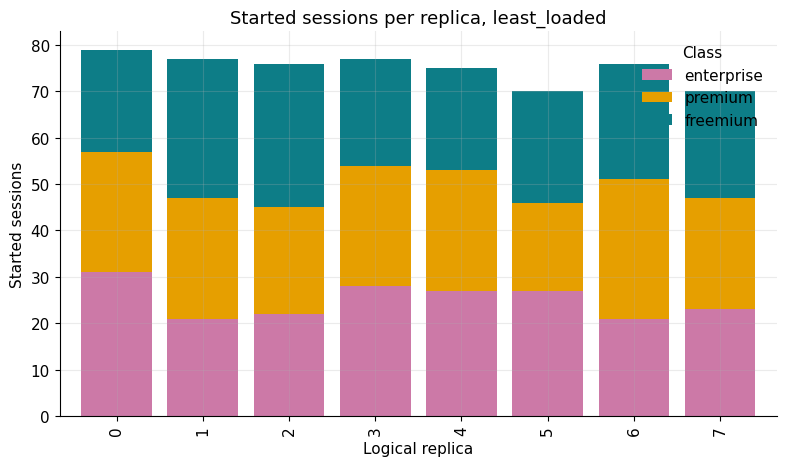

In [4]:
started = decisions[decisions["event"] == "start"].copy()
started["replica"] = started["replica"].astype(int)

for policy in POLICIES:
    df = started[started["policy"] == policy]
    table = (
        df.groupby(["replica", "class"])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=CLASS_ORDER, fill_value=0)
        .sort_index()
    )

    ax = table.plot(
        kind="bar",
        stacked=True,
        color=[CLASS_PALETTE.get(c, None) for c in table.columns],
        width=0.82,
    )
    ax.set_title(f"Started sessions per replica, {policy}")
    ax.set_xlabel("Logical replica")
    ax.set_ylabel("Started sessions")
    ax.legend(title="Class")
    plt.tight_layout()
    plt.savefig(OUT / f"{policy}_started_sessions_per_replica.png", dpi=220)
    plt.show()

## Build active-session time series

In [5]:
def build_snapshots(df):
    df = df.sort_values(["time_s", "event"]).reset_index(drop=True)

    active_jobs = {}
    active = defaultdict(int)
    snapshots = []
    intervals = []
    prev_t = 0.0

    def snapshot(t):
        row = {"time_s": t}
        replicas = sorted({r for r, _ in active.keys()})
        classes = sorted({c for _, c in active.keys()})
        for r in replicas:
            total = sum(active[(r, c)] for c in classes)
            row[f"replica_{r}"] = total
            for c in classes:
                row[f"replica_{r}__{c}"] = active[(r, c)]
        for c in classes:
            row[f"class__{c}"] = sum(active[(r, c)] for r in replicas)
        row["total"] = sum(active.values())
        return row

    snapshots.append(snapshot(0.0))

    for _, row in df.iterrows():
        t = float(row["time_s"])
        if t > prev_t:
            intervals.append((prev_t, t, dict(active)))
            prev_t = t

        event = row["event"]
        job_id = row["job_id"]

        if event == "start":
            cls = row["class"]
            replica = int(row["replica"])
            active_jobs[job_id] = (cls, replica)
            active[(replica, cls)] += 1
        elif event == "finish" and job_id in active_jobs:
            cls, replica = active_jobs.pop(job_id)
            active[(replica, cls)] -= 1
            if active[(replica, cls)] <= 0:
                active.pop((replica, cls), None)

        snapshots.append(snapshot(t))

    snap_df = pd.DataFrame(snapshots).fillna(0).sort_values("time_s")
    return snap_df, intervals

snapshots = {}
intervals = {}

for policy in POLICIES:
    df = decisions[decisions["policy"] == policy]
    snapshots[policy], intervals[policy] = build_snapshots(df)

## Active sessions per replica over time

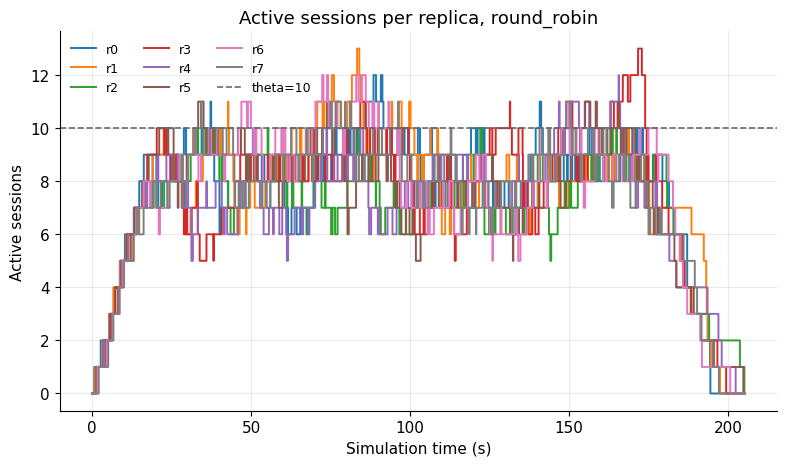

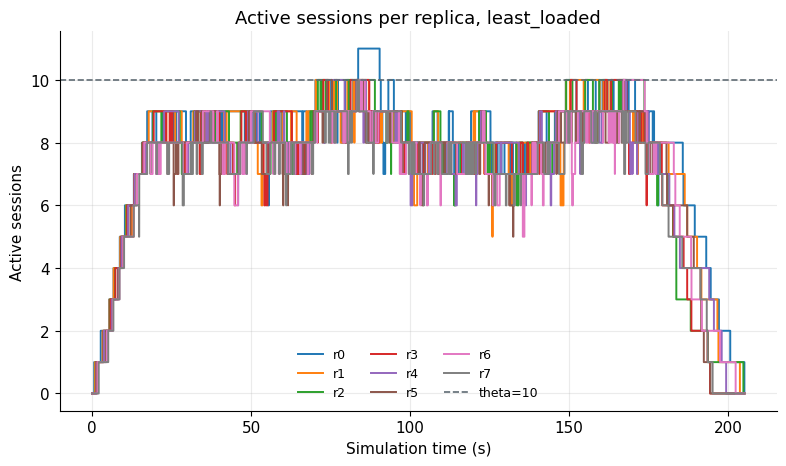

In [6]:
for policy in POLICIES:
    snap = snapshots[policy]
    replica_cols = [c for c in snap.columns if c.startswith("replica_") and "__" not in c]

    fig, ax = plt.subplots()
    for col in replica_cols:
        ax.step(snap["time_s"], snap[col], where="post", linewidth=1.4, label=col.replace("replica_", "r"))
    ax.axhline(THETA, linestyle="--", linewidth=1.2, color=GRAY_COLORS["dark"], label=f"theta={THETA}")
    ax.set_title(f"Active sessions per replica, {policy}")
    ax.set_xlabel("Simulation time (s)")
    ax.set_ylabel("Active sessions")
    ax.legend(ncol=3, fontsize=9)
    plt.tight_layout()
    plt.savefig(OUT / f"{policy}_active_sessions_per_replica.png", dpi=220)
    plt.show()

## Active sessions by class over time

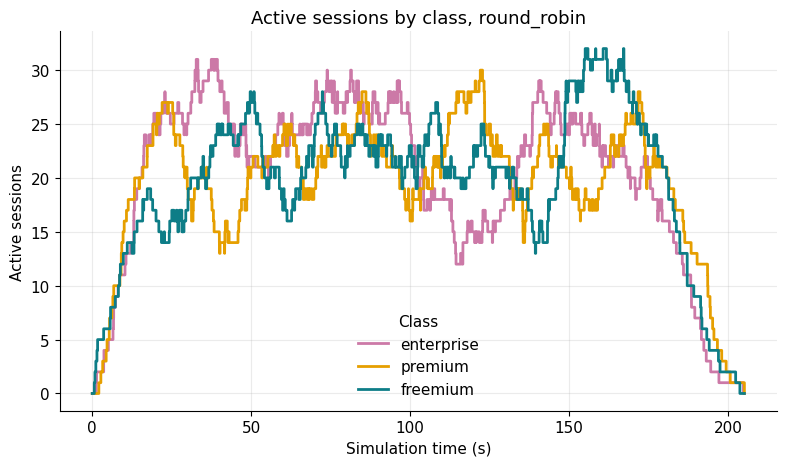

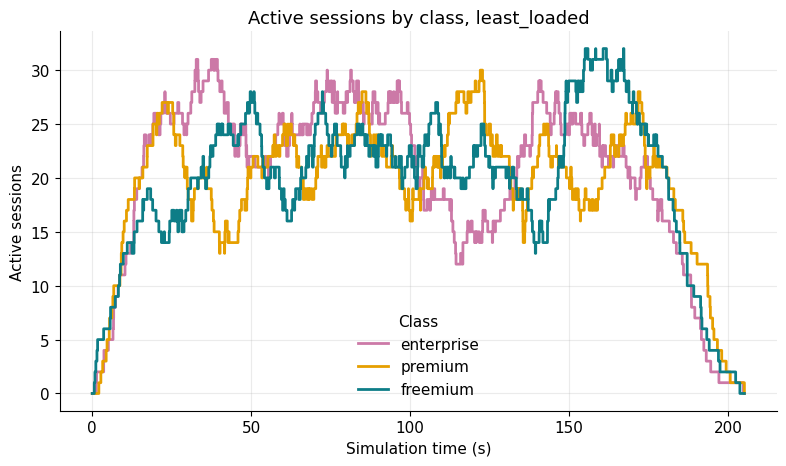

In [7]:
for policy in POLICIES:
    snap = snapshots[policy]
    class_cols = [f"class__{c}" for c in CLASS_ORDER if f"class__{c}" in snap.columns]

    fig, ax = plt.subplots()
    for col in class_cols:
        cls = col.replace("class__", "")
        ax.step(
            snap["time_s"],
            snap[col],
            where="post",
            linewidth=2.0,
            label=cls,
            color=CLASS_PALETTE.get(cls, None),
        )
    ax.set_title(f"Active sessions by class, {policy}")
    ax.set_xlabel("Simulation time (s)")
    ax.set_ylabel("Active sessions")
    ax.legend(title="Class")
    plt.tight_layout()
    plt.savefig(OUT / f"{policy}_active_sessions_by_class.png", dpi=220)
    plt.show()

## Saturation exposure by class

Exposure = fraction of a class's session-seconds spent on replicas whose total active sessions are above theta.

In [8]:
def saturation_exposure(intervals_for_policy, theta):
    total = defaultdict(float)
    saturated = defaultdict(float)

    for t0, t1, active in intervals_for_policy:
        dt = t1 - t0
        if dt <= 0:
            continue

        replicas = sorted({r for r, _ in active.keys()})
        classes = sorted({c for _, c in active.keys()})

        for r in replicas:
            replica_total = sum(active.get((r, c), 0) for c in classes)
            is_saturated = replica_total >= theta

            for c in classes:
                count = active.get((r, c), 0)
                total[c] += count * dt
                if is_saturated:
                    saturated[c] += count * dt

    rows = []
    for c in sorted(total):
        rows.append({
            "class": c,
            "session_seconds": total[c],
            "saturated_session_seconds": saturated[c],
            "saturation_exposure_pct": 100 * saturated[c] / total[c] if total[c] else 0.0,
        })
    return pd.DataFrame(rows)

exposure = []
for policy in POLICIES:
    df = saturation_exposure(intervals[policy], THETA)
    df["policy"] = policy
    exposure.append(df)

exposure = pd.concat(exposure, ignore_index=True)
exposure["class"] = pd.Categorical(exposure["class"], categories=CLASS_ORDER, ordered=True)
exposure = exposure.sort_values(["policy", "class"])
exposure

,class,session_seconds,saturated_session_seconds,saturation_exposure_pct,policy
3,enterprise,4105.605560,407.753054,9.931618,least_loaded
5,premium,3964.049606,413.918596,10.441812,least_loaded
4,freemium,4000.895162,411.125931,10.275849,least_loaded
0,enterprise,4105.605560,905.724703,22.060685,round_robin
2,premium,3964.049606,827.898353,20.885166,round_robin
1,freemium,4000.895162,833.009920,20.820589,round_robin


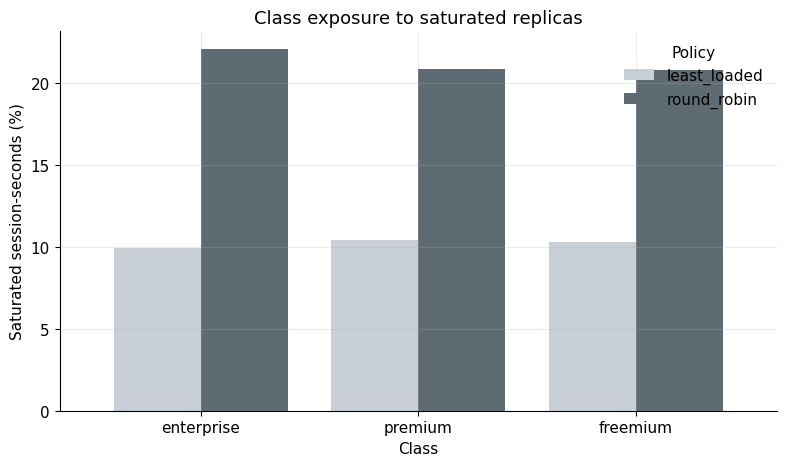

In [9]:
pivot = (
    exposure.pivot(index="class", columns="policy", values="saturation_exposure_pct")
    .reindex(CLASS_ORDER)
)

ax = pivot.plot(
    kind="bar",
    color=[POLICY_PALETTE.get(p, None) for p in pivot.columns],
    width=0.8,
)
ax.set_title("Class exposure to saturated replicas")
ax.set_xlabel("Class")
ax.set_ylabel("Saturated session-seconds (%)")
ax.legend(title="Policy")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUT / "comparison_saturation_exposure_by_class.png", dpi=220)
plt.show()

## Replica load summary

In [10]:
summary_rows = []

for policy in POLICIES:
    snap = snapshots[policy]
    replica_cols = [c for c in snap.columns if c.startswith("replica_") and "__" not in c]
    for col in replica_cols:
        values = snap[col]
        summary_rows.append({
            "policy": policy,
            "replica": col.replace("replica_", "r"),
            "max_active": values.max(),
            "mean_active": values.mean(),
            "p95_active": values.quantile(0.95),
            "time_points_above_theta": (values >= THETA).mean() * 100,
        })

replica_summary = pd.DataFrame(summary_rows)
replica_summary

,policy,replica,max_active,mean_active,p95_active,time_points_above_theta
0,round_robin,r0,12.0,8.139051,10.0,17.735221
1,round_robin,r1,13.0,8.210658,11.0,23.730225
2,round_robin,r2,10.0,7.462115,9.0,3.164030
3,round_robin,r3,13.0,8.112406,11.0,22.231474
4,round_robin,r4,12.0,7.550375,10.0,11.990008
5,round_robin,r5,11.0,7.826811,10.0,16.569525
6,round_robin,r6,12.0,8.149042,11.0,25.395504
7,round_robin,r7,11.0,8.026644,10.0,19.816819
8,least_loaded,r0,11.0,8.452123,10.0,19.650291
9,least_loaded,r1,10.0,8.249792,10.0,15.237302


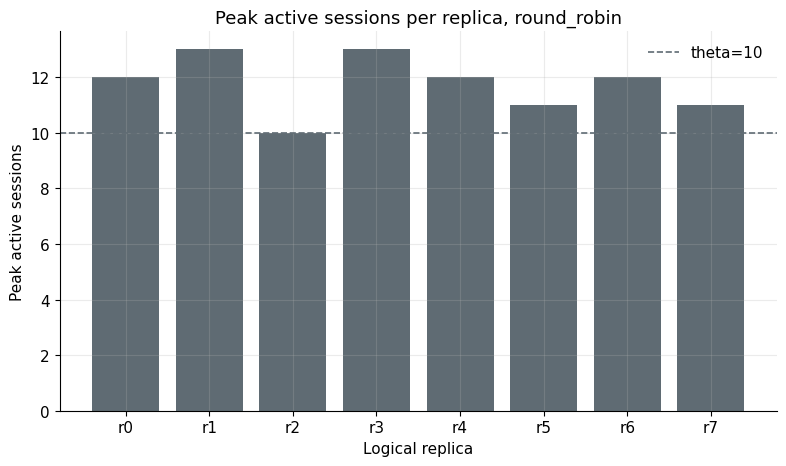

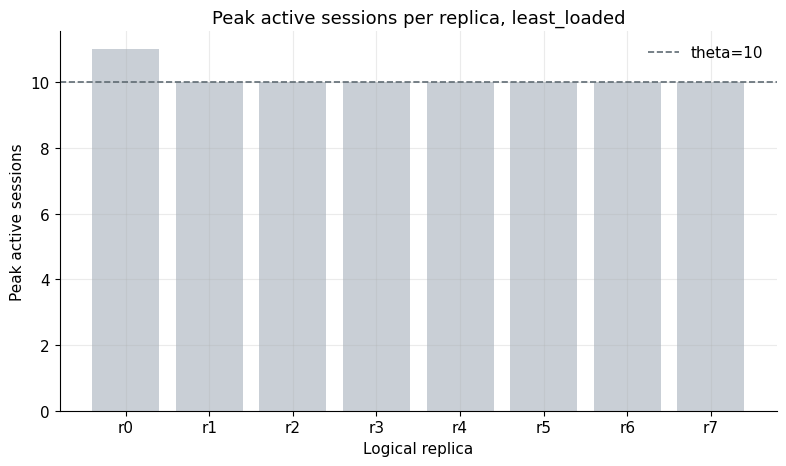

In [11]:
for policy in POLICIES:
    df = replica_summary[replica_summary["policy"] == policy].copy()
    fig, ax = plt.subplots()
    ax.bar(df["replica"], df["max_active"], color=POLICY_PALETTE.get(policy, None))
    ax.axhline(THETA, linestyle="--", linewidth=1.2, color=GRAY_COLORS["dark"], label=f"theta={THETA}")
    ax.set_title(f"Peak active sessions per replica, {policy}")
    ax.set_xlabel("Logical replica")
    ax.set_ylabel("Peak active sessions")
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUT / f"{policy}_peak_active_sessions_per_replica.png", dpi=220)
    plt.show()

## Load imbalance over time

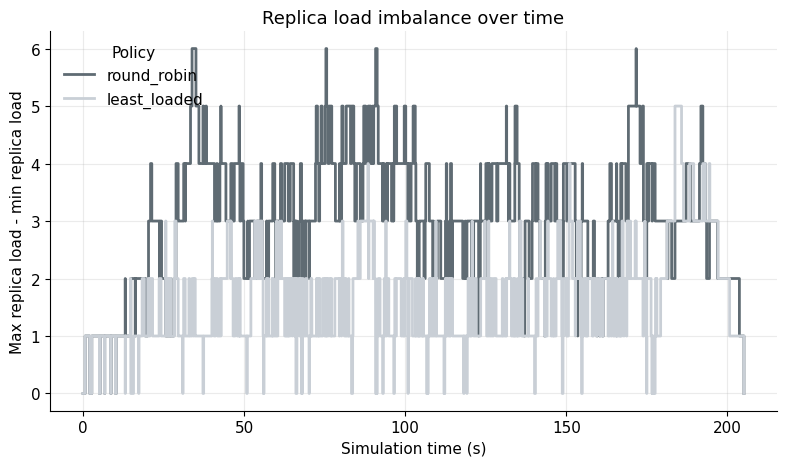

In [12]:
imbalance_rows = []

for policy in POLICIES:
    snap = snapshots[policy].copy()
    replica_cols = [c for c in snap.columns if c.startswith("replica_") and "__" not in c]
    snap["max_replica_load"] = snap[replica_cols].max(axis=1)
    snap["min_replica_load"] = snap[replica_cols].min(axis=1)
    snap["imbalance"] = snap["max_replica_load"] - snap["min_replica_load"]
    snap["policy"] = policy
    imbalance_rows.append(snap[["policy", "time_s", "imbalance"]])

imbalance = pd.concat(imbalance_rows, ignore_index=True)

fig, ax = plt.subplots()
for policy in POLICIES:
    df = imbalance[imbalance["policy"] == policy]
    ax.step(
        df["time_s"],
        df["imbalance"],
        where="post",
        linewidth=2,
        label=policy,
        color=POLICY_PALETTE.get(policy, None),
    )

ax.set_title("Replica load imbalance over time")
ax.set_xlabel("Simulation time (s)")
ax.set_ylabel("Max replica load - min replica load")
ax.legend(title="Policy")
plt.tight_layout()
plt.savefig(OUT / "comparison_load_imbalance_over_time.png", dpi=220)
plt.show()

## Save analysis tables

In [13]:
exposure.to_csv(OUT / "saturation_exposure_by_class.csv", index=False)
replica_summary.to_csv(OUT / "replica_load_summary.csv", index=False)

print(f"Saved plots and tables to: {OUT}")

Saved plots and tables to: /home/spirals/phd/experiments/plb_batsim/notebook_plots/no_fault_3_classes
